# Evaluate the created isochrones against existing data and with results from varioues days

In [1]:
import geopandas as gpd
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shapely

from config import *

In [23]:
file = "all_regions_20241023.gpkg"
file = "all_regions_20240210.gpkg"

In [7]:
# load gpkg
def load_isochrones(file):
    """
    Load isochrones from gpkg file and preprocess for area calculation

    Parameters
        file (str): name of file in out/isochrones_gpkg/ folder
    Returns
        isochrones (gpd.GeoDataFrame): isochrones with additional column "ptsql"
    """
    isochrones = gpd.read_file(f"{PATH_OUT_ISOCHRONES}{file}")
    isochrones = isochrones.iloc[1:]
    isochrones['ptsql'] = isochrones['color'].apply(lambda x: [key for key, value in PTSQL_COLORS_DICT.items() if value == x][0])
    isochrones = isochrones.sort_values("ptsql", ascending=True)
    isochrones = isochrones.reset_index().drop(columns=['index'])
    return isochrones

def load_population():
    """
    Load population from gpkg file
    """
    population = gpd.read_file(PATH_IN_POPULATION + "Eurostat_Census-GRID_2021_V2.2/ESTAT_Census_2021_V2.gpkg")

    coords = population["GRD_ID"].str.extract(r"N(\d+)E(\d+)").astype(int)
    coords.columns = ["N", "E"]

    mask = (
        (coords["N"].between(MIN_N, MAX_N)) &
        (coords["E"].between(MIN_E, MAX_E))
    )

    population = population[mask]

    population.to_crs(crs=TARGET_CRS, inplace=True)

    population = population[['GRD_ID', 'T', 'geometry']]

    return population

def calculate_areas(isochrones, population=None):
    """
    Calcaulate area of each ptsql category. Starts by last category (G) and subtracts areas of all previous categories.

    Parameters
        isochrones (gpd.GeoDataFrame): isochrones with additional column "ptsql"
        population (gpd.GeoDataFrame): population of each area. If not None, population is calculated for each area (default None)
    Returns
        areas (dict): dictionary of ptsql category and area 
        populations (dict, optional): dictionary of ptsql category and population (if population is not None)
    """

    if population is not None:
        population["centroid"] = population.geometry.centroid

    areas = {}
    populations = {}
    prev_geom = None
    prev_pop = 0
    for row in isochrones.itertuples():
    #for i in range(len(isochrones)):
        if prev_geom is None:
            full_area = row.geometry
            prev_geom = shapely.Polygon(((0,0), (0,0), (0,0)))
        else:
            full_area = shapely.unary_union([prev_geom, row.geometry])

        areas[row.ptsql] = (full_area.area - prev_geom.area)  / 1000000
        prev_geom = full_area

        if population is not None:
            mask = population["centroid"].within(full_area)
            populations[row.ptsql] = round(population.loc[mask, "T"].sum()) - prev_pop
            prev_pop += populations[row.ptsql]


    if population is not None:
        return areas, populations

    return areas

def create_area_df(days, calc_population=False):
    """
    Create dataframe of areas for each ptsql category for each day

    Parameters
        days (list): list of days to read gpkg and calculate areas for
        calc_population (bool): if True, calculate population of each area as well
    Returns
        dfs (pd.DataFrame): dataframe of areas for each ptsql category for each day
    """
    area_dicts = []
    population_dicts = []

    population = load_population() if calc_population else None

    for day in days:
        f = f"all_regions_{day}.gpkg"
        iso = load_isochrones(f)
        dfs = calculate_areas(iso, population)
        if calc_population:
            area_dicts.append(dfs[0])
            population_dicts.append(dfs[1])
        else:
            area_dicts.append(dfs)
    
    if calc_population:
        df_areas = pd.DataFrame(area_dicts)
        df_populations = pd.DataFrame(population_dicts)

        df_areas.insert(0, "date", days)
        df_populations.insert(0, "date", days)

        return df_areas, df_populations
    else:
        df_areas = pd.DataFrame(area_dicts)
        df_areas.insert(0, "date", days)
        return df_areas
    
    

In [8]:
# isochrones = load_isochrones(file)
# display(isochrones)

population = load_population()
display(population.head())

,GRD_ID,T,geometry
876708,CRS3035RES1000mN2250000E3944000,516,"POLYGON ((-247262.297 -38955.557, -246263.021 ..."
876709,CRS3035RES1000mN2250000E3945000,2615,"POLYGON ((-246263.021 -38996.137, -245263.748 ..."
876710,CRS3035RES1000mN2250000E3946000,8654,"POLYGON ((-245263.748 -39036.722, -244264.478 ..."
876711,CRS3035RES1000mN2250000E3947000,4229,"POLYGON ((-244264.478 -39077.314, -243265.212 ..."
876712,CRS3035RES1000mN2250000E3948000,4741,"POLYGON ((-243265.212 -39117.912, -242265.948 ..."


In [5]:
# population stats:
# 'A': 1149694, slow, accuate: 28mins
# 'A': 1149694, faster, accurate: 13mins
# 'A': 1248985, very fast, not fully accurate: 8secs

In [ ]:
df_areas, df_populations = create_area_df(ALL_DAYS, calc_population=True)

In [7]:
display(df_areas)
display(df_populations)

,date,A,B,C,D,E,F,G
0,20240131,209.049844,247.054857,481.579445,916.150082,1403.566185,2248.116482,6127.352496
1,20240215,203.371987,240.004236,465.050045,885.121488,1347.764871,2180.614395,5996.810572
2,20240315,208.113204,246.939722,479.195111,910.693623,1397.027856,2239.822540,6106.594599
3,20240415,203.200051,241.367252,464.927210,881.923520,1368.450269,2216.637002,6090.627088
4,20240515,202.367950,240.347868,461.730886,880.500306,1373.756111,2223.468562,6105.000993
5,20240614,202.592587,240.077749,463.928228,886.467772,1385.092058,2236.018649,6129.576967
6,20240715,174.499553,212.657745,414.385154,781.222789,1169.781707,1894.030504,5283.832367
7,20240814,187.367468,223.899355,427.258607,785.973307,1175.663050,1904.082747,5320.134720
8,20240916,234.018887,264.499285,486.433730,900.359220,1393.412505,2254.607092,6217.154600
9,20241015,233.360722,263.943482,486.051987,889.606820,1379.116732,2238.958944,6184.716478


,date,A,B,C,D,E,F,G
0,20240131,1660692,826456,845339,957549,869344,868689,1206899
1,20240215,1638662,813598,840898,945131,854959,858886,1230204
2,20240315,1649665,830441,844407,968728,856655,865581,1208098
3,20240415,1656573,779963,831915,968909,851645,899008,1218198
4,20240515,1656573,775044,838968,965112,850946,901145,1219931
5,20240614,1650596,765098,842568,976494,858865,896382,1222708
6,20240715,1512273,773865,807041,922637,836667,830086,1252961
7,20240814,1563945,830890,833733,888617,804967,800901,1238707
8,20240916,1791491,885710,851854,898267,829201,846332,1193940
9,20241015,1791491,884269,846397,902463,825314,843186,1198079


In [8]:
# sanity check populations
display(df_populations[['A', 'B', 'C', 'D', 'E', 'F', 'G']].sum(axis=1))

0     7234968
1     7182338
2     7223575
3     7206211
4     7207719
5     7212711
6     6935530
7     6961760
8     7296795
9     7291199
10    7182800
11    7321520
12    7289324
13    6990257
14    6190739
15    5603576
16    6165405
17    5716190
18    6271663
19    5799351
dtype: int64

In [ ]:
# save area df
df_areas.to_csv(f"{PATH_OUT_EVALUATION}area_df.csv", index=False)

df_populations.to_csv(f"{PATH_OUT_EVALUATION}population_df.csv", index=False)

In [9]:
# load the data again

df_areas = pd.read_csv(f"{PATH_OUT_EVALUATION}area_df.csv")
df_populations = pd.read_csv(f"{PATH_OUT_EVALUATION}population_df.csv")

display(df_areas)
display(df_populations)

,date,A,B,C,D,E,F,G
0,20240131,209.049844,247.054857,481.579445,916.150082,1403.566185,2248.116482,6127.352496
1,20240215,203.371987,240.004236,465.050045,885.121488,1347.764871,2180.614395,5996.810572
2,20240315,208.113204,246.939722,479.195111,910.693623,1397.027856,2239.822540,6106.594599
3,20240415,203.200051,241.367252,464.927210,881.923520,1368.450269,2216.637002,6090.627088
4,20240515,202.367950,240.347868,461.730886,880.500306,1373.756111,2223.468562,6105.000993
5,20240614,202.592587,240.077749,463.928228,886.467772,1385.092058,2236.018649,6129.576967
6,20240715,174.499553,212.657745,414.385154,781.222789,1169.781707,1894.030504,5283.832367
7,20240814,187.367468,223.899355,427.258607,785.973307,1175.663050,1904.082747,5320.134720
8,20240916,234.018887,264.499285,486.433730,900.359220,1393.412505,2254.607092,6217.154600
9,20241015,233.360722,263.943482,486.051987,889.606820,1379.116732,2238.958944,6184.716478


,date,A,B,C,D,E,F,G
0,20240131,1660692,826456,845339,957549,869344,868689,1206899
1,20240215,1638662,813598,840898,945131,854959,858886,1230204
2,20240315,1649665,830441,844407,968728,856655,865581,1208098
3,20240415,1656573,779963,831915,968909,851645,899008,1218198
4,20240515,1656573,775044,838968,965112,850946,901145,1219931
5,20240614,1650596,765098,842568,976494,858865,896382,1222708
6,20240715,1512273,773865,807041,922637,836667,830086,1252961
7,20240814,1563945,830890,833733,888617,804967,800901,1238707
8,20240916,1791491,885710,851854,898267,829201,846332,1193940
9,20241015,1791491,884269,846397,902463,825314,843186,1198079


In [10]:
def create_evaluation_plot(df, day1, day2, type='area', matrix=False, note_text=False, percent=False):
    """
    Create a heatmap of the differences between the two days.

    Parameters:
        df (pd.DataFrame): The DataFrame containing the area sizes for each ptsql category as columns and the days as rows. Cols: "date, A, B, C, D, E, F, G".
        day1 (int): The first day for which the areas should be compared. Must match an entry in the "date" column in the DataFrame.
        day2 (int): The second day for which the areas should be compared. Must match an entry in the "date" column in the DataFrame.
        type (str, optional): The type of the data. Can be "area" or "population". Defaults to "area".
        matrix (bool, optional): Whether to return a matrix of differences (squared heatmap) instead of a one-dimensional heatmap. Defaults to False.
        note_text (bool, optional): Whether to add a note to the plot indicating the direction of the differences. Defaults to False.
        percent (bool, optional): Whether to display the differences as percentages instead of absolute values. Defaults to False.
    """
    # TODO: add percentages to matrix plot
    d1 = pd.to_datetime(str(day1))
    d2 = pd.to_datetime(str(day2))

    row_day1 = df[df["date"] == day1].drop(columns=["date"])
    row_day2 = df[df["date"] == day2].drop(columns=["date"])
    labels = row_day1.columns.tolist()

    if matrix:
        # a bit complicated to use and understand, 1d heatmap is better (matrix=False)
        pair_wise_diff = np.subtract.outer(row_day1.values.flatten(), row_day2.values.flatten())
        
        plot = sns.heatmap(pair_wise_diff, annot=True, xticklabels=labels, yticklabels=labels, cmap="coolwarm", center=0, fmt=".1f")
        plt.xlabel(f"PTSQL {d2.date()}")
        plt.ylabel(f"PTSQL {d1.date()}")
    else:
        if percent:
            diff = row_day1.values / row_day2.values * 100
        else:
            diff = row_day1.values - row_day2.values

        unit = "km²" if type == "area" else "#"
        yticklabels = ["Difference [%]" if percent else f"Difference [{unit}]"]

        plot = sns.heatmap(diff, annot=True, xticklabels=labels, yticklabels=yticklabels, 
                           cmap="coolwarm", fmt=".0f" if type == 'population' and not percent else ".1f",)

        for text in plot.texts:
            text.set_rotation(45)

        plt.xlabel("PTSQL")

    plt.title(f"Difference of {type} between {d1.date()} and {d2.date()}")
    if note_text:
        if percent:
            text = f"Values greater than 100% indicate a larger {type} for {d1.date()}."
        else:
            text = f"Positive values indicate a larger {type} for {d1.date()}."

        plt.figtext(x=0.5, y=-0.02, s=text, ha="center", fontsize=10)

    return plot

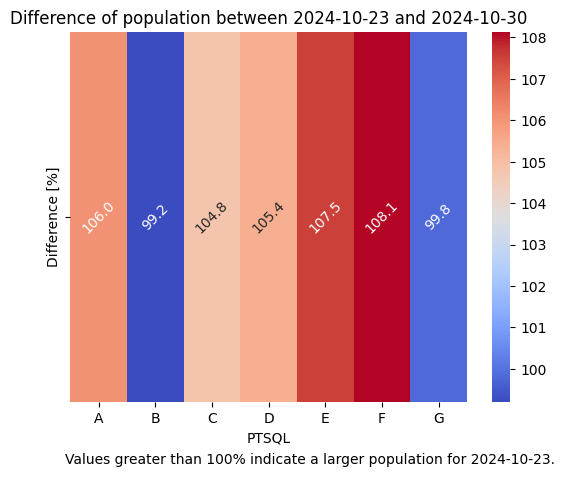

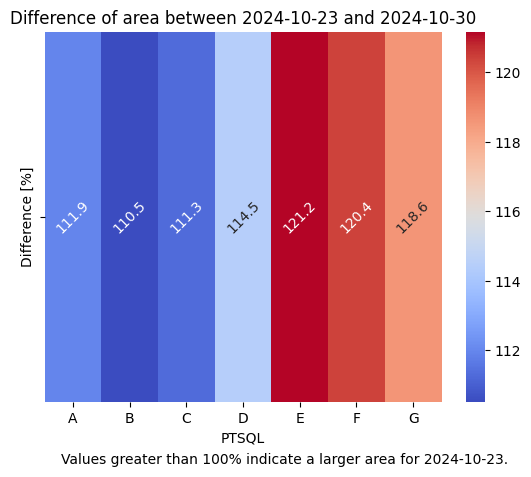

In [11]:
p1 = create_evaluation_plot(df_populations, 20241023, 20241030, type='population', percent=True, note_text=True)
plt.show()

p2 = create_evaluation_plot(df_areas, 20241023, 20241030, type='area', percent=True, note_text=True)
plt.show()

In [12]:
def create_time_series_plot(df, days=[], type='area', day_names=True, plot_size: str|tuple = 'auto', bar_labels=False, groupby=None, custom_labels=None, custom_title=None, rotate_bar_labels=False):
    """
    Creates a time series plot from a dataframe for the given days.

    Parameters:
        df (pandas.DataFrame): Dataframe containing the data to plot.
        days (list): List of days to plot. If empty, all days are plotted. Default is [].
        type (str, optional): The type of the data. Can be "area" or "population". Defaults to "area".
        day_names (bool): Whether to show day names on the x-axis.
        plot_size (tuple or str): Size of the plot. If 'auto', the plot size is automatically adjusted. Else provide a tuple of (width, height). Default is 'auto'.
        bar_labels (bool): Whether to show labels in the bar segments. Default is False.
        groupby (str): Place closer to each other bars by this criterea. Either 'month' or 'day'. Default is None.
        custom_labels (list): Custom labels added to the date tick labels. If provided, must match the number of x ticks. Default is None.
        custom_title (str): Custom title for the plot. Default is None.
        rotate_bar_labels (bool): Whether to rotate the bar labels. Default is False.

    Returns:
        matplotlib.axes.Axes: Axes object containing the plot.
    """
    if len(days) == 0:
        days = list(df.date.values)

    if plot_size == 'auto':
        x_size = max(len(days) - 2, 6)
        y_size = x_size*0.6
    else:
        x_size = plot_size[0]
        y_size = plot_size[1]

    df_filtered = df[df.date.isin(days)].sort_values(by='date')
    dates = list(pd.to_datetime(df_filtered.date, format='ISO8601'))

    x = []
    pos = 0
    prev = None
    for d in dates:
        current = None
        if groupby == 'month':
            current = d.month
        elif groupby == 'day':
            current = d.day
        else:
            pos += 1
            x.append(pos)
            continue

        if prev is not None and current != prev :
            pos += 1.2   # month gap
        else:
            pos += 0.7   # normal gap
        x.append(pos)
        prev = current

    df_filtered['x_pos'] = x

    value_cols = [c for c in df_filtered.columns if c not in ['date', 'month', 'x_pos']]

    #ax = df_filtered.plot(kind='bar', x='x_pos', y=value_cols, stacked=True, color=PTSQL_COLORS, figsize=(x_size, y_size))

    fig, ax = plt.subplots(figsize=(x_size, y_size))

    bottom = np.zeros(len(df_filtered))

    for col, color in zip(value_cols, PTSQL_COLORS_DICT.values()):
        values = df_filtered[col].values
        ax.bar(df_filtered['x_pos'], values,
            bottom=bottom,
            width=0.6,
            color=color,
            label=col)
        bottom += values

    if day_names:
        #dates = list(pd.to_datetime(df_filtered.date, format='ISO8601'))
        day_names = [d.strftime("%A") for d in dates]
        x_ticks = [str(d.date()) + "\n" + n for d, n in zip(dates, day_names)]
        if custom_labels is not None:
            x_ticks = [l + "\n" + x for x, l in zip(x_ticks, custom_labels)]
        ax.set_xticks(x, x_ticks, rotation=45)
    else:
        x_ticks = [str(d.date()) for d in dates]
        if custom_labels is not None:
            x_ticks = [l + "\n" + x for x, l in zip(x_ticks, custom_labels)]
        ax.set_xticks(x, x_ticks, rotation=45)

    if bar_labels:
        fig.canvas.draw()
        offset_text = ax.yaxis.get_offset_text().get_text()

        for c in ax.containers:
            # Optional: if the segment is small or 0, customize the labels
            labels_texts = [int(v.get_height()) if v.get_height() > 500 else '' for v in c]

            if offset_text.startswith('1e'):
                labels_texts = ["{:.2e}".format(v).replace('+0','') if v != '' else '' for v in labels_texts]  
            
            # remove the labels parameter if it's not needed for customized labels
            ax.bar_label(c, labels=labels_texts, label_type='center', rotation=45 if rotate_bar_labels else 0)

    ax.set_axisbelow(True)
    ax.grid(axis='y', color='gray', linestyle='--')
    plt.ylabel('Area [km²]' if type == 'area' else 'Population [#]')
    plt.legend(loc="center left", bbox_to_anchor=(1,0.6), title="PTSQL")

    if custom_title is not None:
        plt.title(custom_title)
    else:
        plt.title(f'Time Series plot for {type}')

    return ax

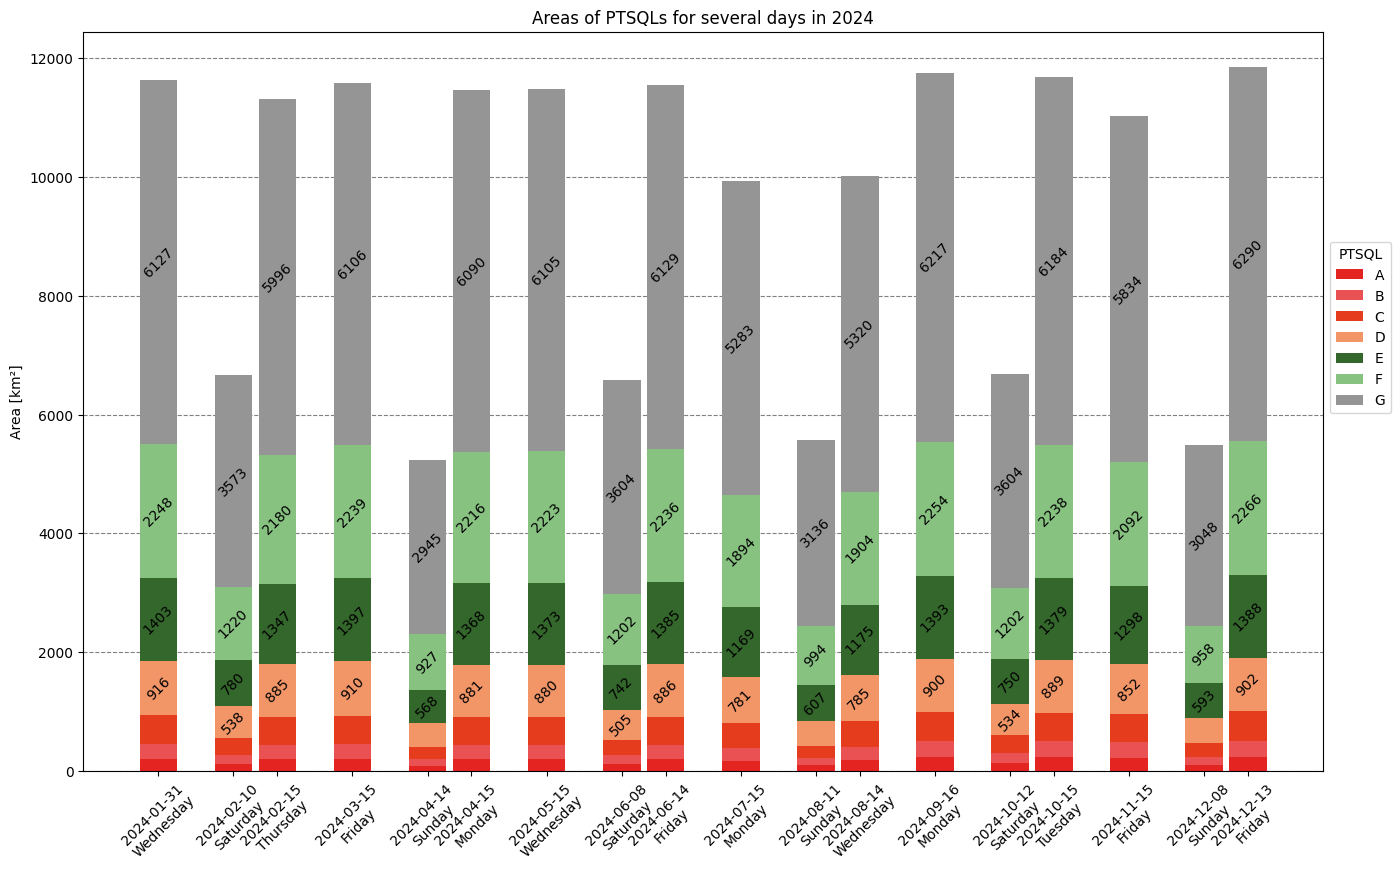

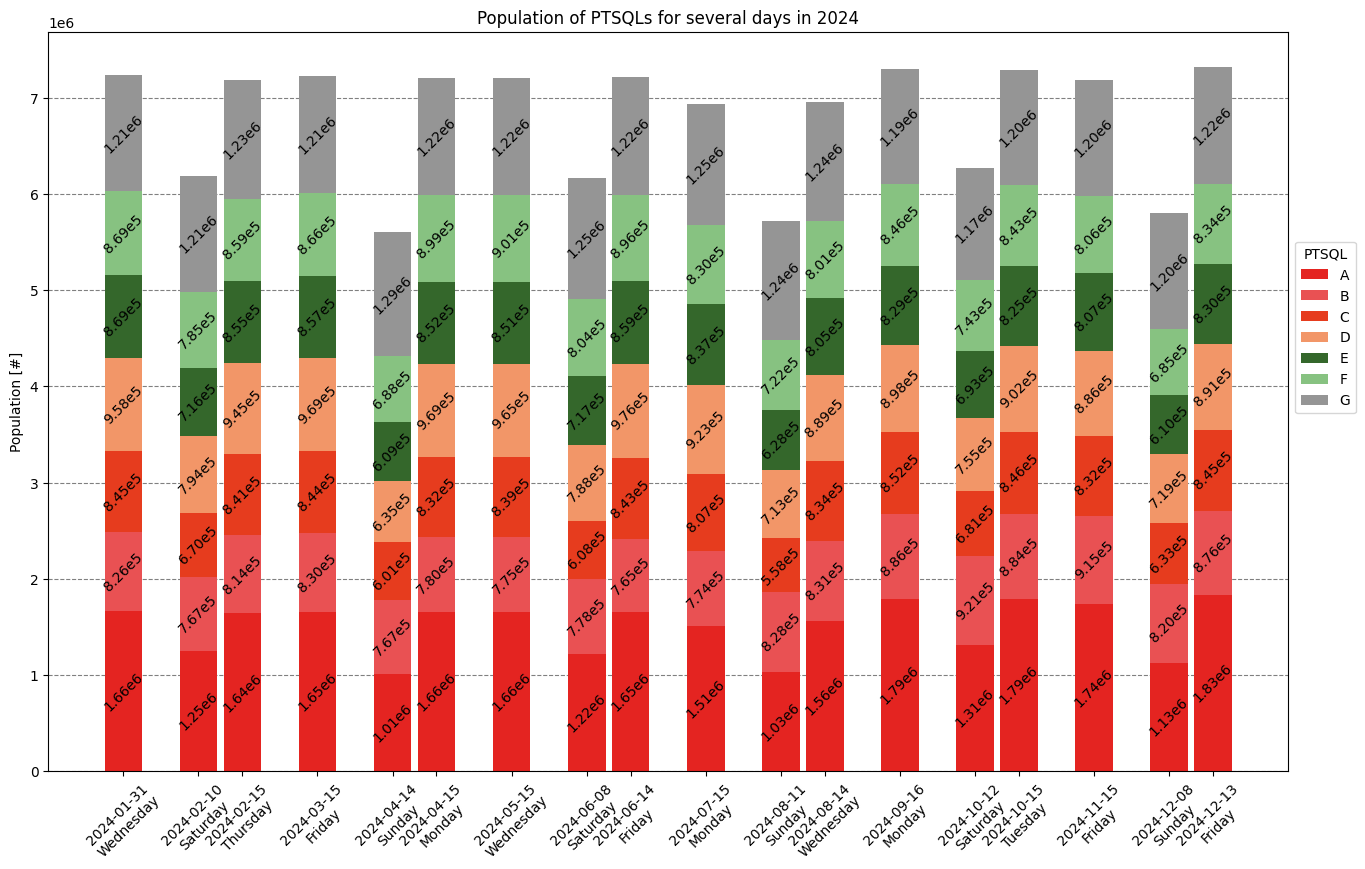

In [13]:
p3 = create_time_series_plot(df_areas, days=WEEKDAYS + WEEKENDS, type="area", day_names=True, 
                             plot_size='auto', bar_labels=True, groupby='month', rotate_bar_labels=True, 
                             custom_title="Areas of PTSQLs for several days in 2024")
plt.show()
p4 = create_time_series_plot(df_populations, days=WEEKDAYS + WEEKENDS, type="population", day_names=True, 
                             plot_size='auto', bar_labels=True, groupby='month', rotate_bar_labels=True,
                             custom_title="Population of PTSQLs for several days in 2024")
plt.show()

In [14]:
# load and check existing solution of oerok

oerok_isochrones_20241023 = gpd.read_file(PATH_IN_OEROK + "OeV_Gueteklassen_Polygone_20241023.shp")
oerok_isochrones_20241030 = gpd.read_file(PATH_IN_OEROK + "OeV_Gueteklassen_Polygone_20241030.shp")
display(oerok_isochrones_20241030)

,MIN_katego,Shape_Leng,Shape_Area,gueteklass,geometry
0,1,1.079533e+06,1.329685e+08,A,"MULTIPOLYGON (((4614507.864 2615644.015, 46144..."
1,2,3.413539e+06,2.415568e+08,B,"MULTIPOLYGON (((4621198.93 2613694.349, 462124..."
2,3,7.046424e+06,4.541384e+08,C,"MULTIPOLYGON (((4651018.937 2611226.685, 46510..."
3,4,1.323202e+07,8.103399e+08,D,"MULTIPOLYGON (((4641131.59 2610285.073, 464113..."
4,5,2.132727e+07,1.250353e+09,E,"MULTIPOLYGON (((4641182.509 2610310.554, 46412..."
5,6,3.451875e+07,2.089770e+09,F,"MULTIPOLYGON (((4657556.258 2604661.115, 46576..."
6,7,5.234422e+07,5.098685e+09,G,"MULTIPOLYGON (((4662454.686 2606776.823, 46624..."


In [15]:
oerok_isochrones_20241023.rename(columns={'gueteklass': 'ptsql'}, inplace=True)
oerok_isochrones_20241030.rename(columns={'gueteklass': 'ptsql'}, inplace=True)

oerok_isochrones_20241023.to_crs(crs=TARGET_CRS, inplace=True)
oerok_isochrones_20241030.to_crs(crs=TARGET_CRS, inplace=True)

In [47]:
oerok_areas_20241023, oerok_populations_20241023 = calculate_areas(oerok_isochrones_20241023, population=population)
oerok_areas_20241030, oerok_populations_20241030 = calculate_areas(oerok_isochrones_20241030, population=population)

In [16]:
df_existing_areas = pd.DataFrame([oerok_areas_20241023, oerok_areas_20241030])
df_existing_populations = pd.DataFrame([oerok_populations_20241023, oerok_populations_20241030])

df_existing_areas.insert(0, "date", OEROK_DAYS)
df_existing_populations.insert(0, "date", OEROK_DAYS)

display(df_existing_areas)
display(df_existing_populations)

NameError: name 'oerok_areas_20241023' is not defined

In [17]:
# save dfs
df_existing_areas.to_csv(f"{PATH_OUT_EVALUATION}oerok_area.csv", index=False)

df_existing_populations.to_csv(f"{PATH_OUT_EVALUATION}oerok_population.csv", index=False)

NameError: name 'df_existing_areas' is not defined

In [18]:
# load dfs
df_existing_areas = pd.read_csv(f"{PATH_OUT_EVALUATION}oerok_area.csv")

df_existing_populations = pd.read_csv(f"{PATH_OUT_EVALUATION}oerok_population.csv")

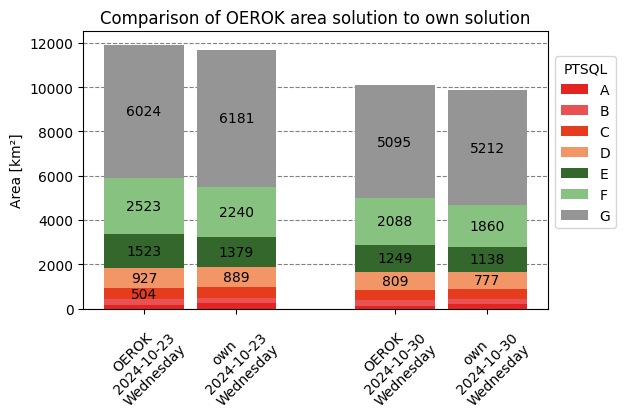

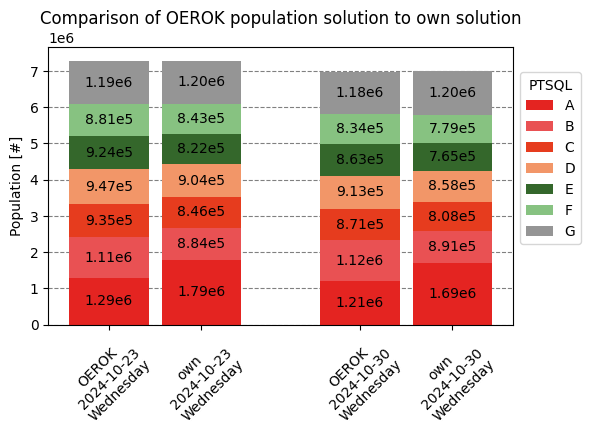

In [19]:
df_a = pd.concat([df_existing_areas, df_areas], axis=0)
df_p = pd.concat([df_existing_populations, df_populations], axis=0)

custom_labels = ["OEROK", "own", "OEROK", "own"]

p5 = create_time_series_plot(df_a, days=OEROK_DAYS, type="area", day_names=True, plot_size='auto',
                              bar_labels=True, groupby='day', custom_labels=custom_labels,
                              custom_title="Comparison of OEROK area solution to own solution")  
plt.show()
p6 = create_time_series_plot(df_p, days=OEROK_DAYS, type="population", day_names=True, plot_size='auto',
                              bar_labels=True, groupby='day', custom_labels=custom_labels,
                              custom_title="Comparison of OEROK population solution to own solution")
plt.show()

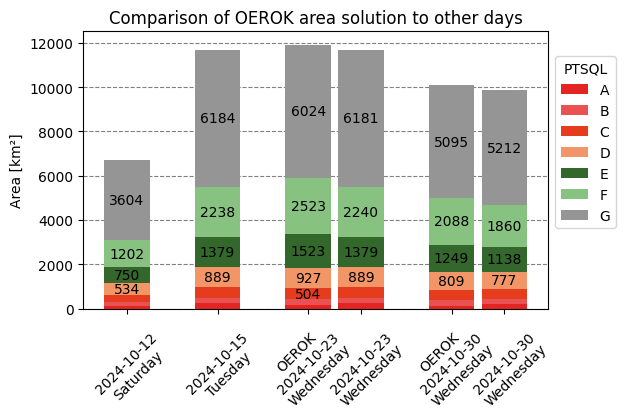

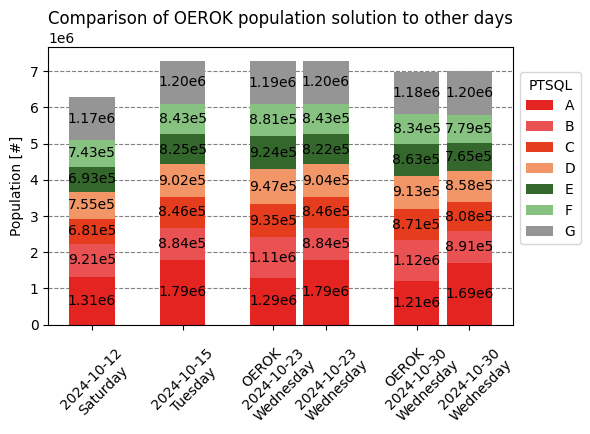

In [20]:
custom_labels = ["", "", "OEROK", "", "OEROK", ""]

p7 = create_time_series_plot(df_a, days=OEROK_DAYS + [20241012, 20241015], type="area", day_names=True, plot_size='auto',
                              bar_labels=True, groupby='day', custom_labels=custom_labels,
                              custom_title="Comparison of OEROK area solution to other days")  
plt.show()
p8 = create_time_series_plot(df_p, days=OEROK_DAYS + [20241012, 20241015], type="population", day_names=True, plot_size='auto',
                              bar_labels=True, groupby='day', custom_labels=custom_labels,
                              custom_title="Comparison of OEROK population solution to other days")
plt.show()

In [21]:
def statistics(df_area, df_population, week_days=WEEKDAYS, weekends=WEEKENDS):

    dfs = []

    for i, df in enumerate([df_area, df_population]):

        avg_weekday = df[df.date.isin(week_days)].mean()
        min_weekday = df[df.date.isin(week_days)].min()
        max_weekday = df[df.date.isin(week_days)].max()
        std_weekday = df[df.date.isin(week_days)].std()

        avg_weekend = df[df.date.isin(weekends)].mean()
        min_weekend = df[df.date.isin(weekends)].min()
        max_weekend = df[df.date.isin(weekends)].max()
        std_weekend = df[df.date.isin(weekends)].std()

        df_new = pd.DataFrame({'avg_weekday': avg_weekday, 'min_weekday': min_weekday, 'max_weekday': max_weekday, 'std_weekday': std_weekday,
                            'avg_weekend': avg_weekend, 'min_weekend': min_weekend, 'max_weekend': max_weekend, 'std_weekend': std_weekend})

        df_new = (
            df_new
            .reset_index(names="group")
            .melt(id_vars="group")
            .assign(
                statistic=lambda x: x["variable"].str.split("_").str[0],
                day=lambda x: x["variable"].str.split("_").str[1]
            )
            .pivot(index=["statistic", "day"], columns="group", values="value")
            .reset_index()
            .drop(columns=["date"])
            .rename_axis(None, axis=1)
        )

        if i == 0:
            df_new.insert(0, "type", "area")
        else:
            df_new.insert(0, "type", "population")

        dfs.append(df_new)

    df_final = pd.concat(dfs)

    return df_final
    

In [22]:
df_area_stats = statistics(df_areas, df_populations)
df_area_stats

,type,statistic,day,A,B,C,D,E,F,G
0,area,avg,weekday,2.101164e+02,245.676097,466.629797,872.752194,1340.047276,2166.249643,5.973954e+03
1,area,avg,weekend,1.096555e+02,140.377555,247.582848,467.814059,673.647700,1084.124603,3.318620e+03
2,area,max,weekday,2.407805e+02,267.933665,494.653411,916.150082,1403.566185,2266.444610,6.290752e+03
3,area,max,weekend,1.355118e+02,168.282861,294.442628,538.389030,780.421407,1220.718790,3.604689e+03
4,area,min,weekday,1.744996e+02,212.657745,414.385154,781.222789,1169.781707,1894.030504,5.283832e+03
5,area,min,weekend,8.944660e+01,118.928311,203.784096,390.751945,568.006919,927.171368,2.945090e+03
6,area,std,weekday,1.956525e+01,16.651038,23.954918,44.746834,83.034446,132.957192,3.335301e+02
7,area,std,weekend,1.828211e+01,18.619610,37.854274,65.715922,93.979431,137.815930,3.079396e+02
0,population,avg,weekday,1.678309e+06,829746.666667,838309.000000,930910.500000,839598.750000,854205.333333,1.217014e+06
1,population,avg,weekend,1.158656e+06,813396.166667,625122.333333,733855.333333,662269.333333,737739.833333,1.226782e+06


In [ ]:
df_area_stats.to_csv(PATH_OUT_EVALUATION + 'statistics.csv', index=False)

In [ ]:
def calculate_areas(isochrones, population=None):
    """
    Calcaulate area of each ptsql category. Starts by last category (G) and subtracts areas of all previous categories.

    Parameters
        isochrones (gpd.GeoDataFrame): isochrones with additional column "ptsql"
        population (gpd.GeoDataFrame): population of each area. If not None, population is calculated for each area (default None)
    Returns
        areas (dict): dictionary of ptsql category and area
    """
    #isochrones = isochrones.sort_values("ptsql", ascending=False)

    areas = {}
    populations = {}
    prev_geom = None
    prev_pop = 0
    for row in isochrones.itertuples():
    #for i in range(len(isochrones)):
        if row.Index == 0:
            full_area = row.geometry

            areas[row.ptsql] = full_area.area / 1000000

            prev_geom = full_area
        else:
            full_area = shapely.unary_union([prev_geom, row.geometry])

            areas[row.ptsql] = (full_area.area - prev_geom.area)  / 1000000

            prev_geom = full_area

        if population is not None:
            intersection = gpd.overlay(population, gpd.GeoDataFrame(geometry=[full_area], crs=TARGET_CRS), how="intersection")
            new_area = intersection.geometry.area

            # adjust population in square km if not fully contained in intersection by ratio of square km to contained area
            pop_adjusted = intersection["T"] * (new_area / 1000000)  # original area = 1000000 m^2 for 1km^2

            populations[row.ptsql] = round(pop_adjusted.sum()) - prev_pop
            prev_pop += populations[row.ptsql]

    if population is not None:
        return dict(reversed(areas.items())), dict(reversed(populations.items()))

    return areas